<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:79: SyntaxWarning: invalid escape sequence '\g'
<>:79: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_1399/630744048.py:79: SyntaxWarning: invalid escape sequence '\g'
  plt.ylabel("Semivariance $\gamma(h)$", fontsize=11)


Silakan upload file 'cities.csv' Anda:


Saving cities.csv to cities.csv

--- EVALUASI HUBUNGAN VARIABEL ---
Korelasi Pearson (r): 0.9997
Jumlah Stasiun Sampel Utama (Train): 52
Jumlah Stasiun Uji/Prediksi (Test): 98


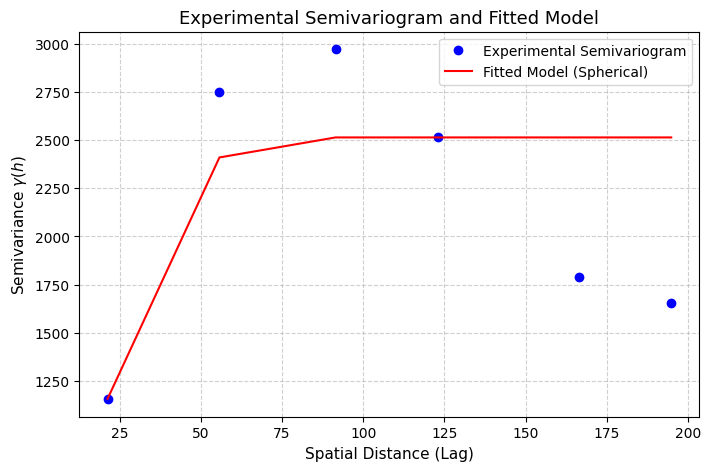


--- PARAMETER VARIOGRAM TERFITTING ---
Model Variogram: spherical
Parameters (Sill, Range, Nugget): [2.51498943e+03 6.72568569e+01 9.55465340e-13]

--- HASIL EVALUASI MODEL CO-KRIGING ---
R-Squared (R²): 0.9994
Root Mean Squared Error (RMSE): 1.2924


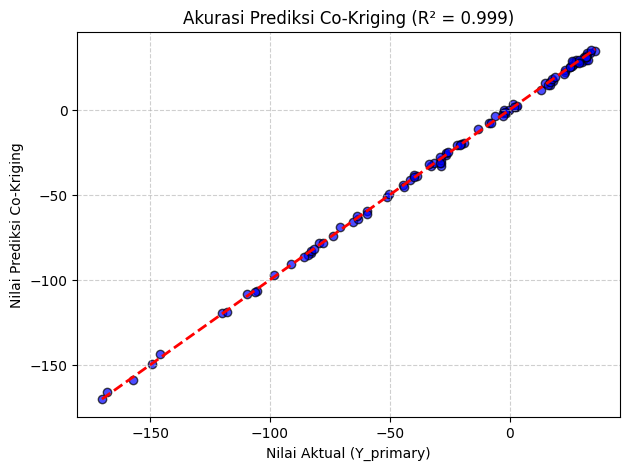

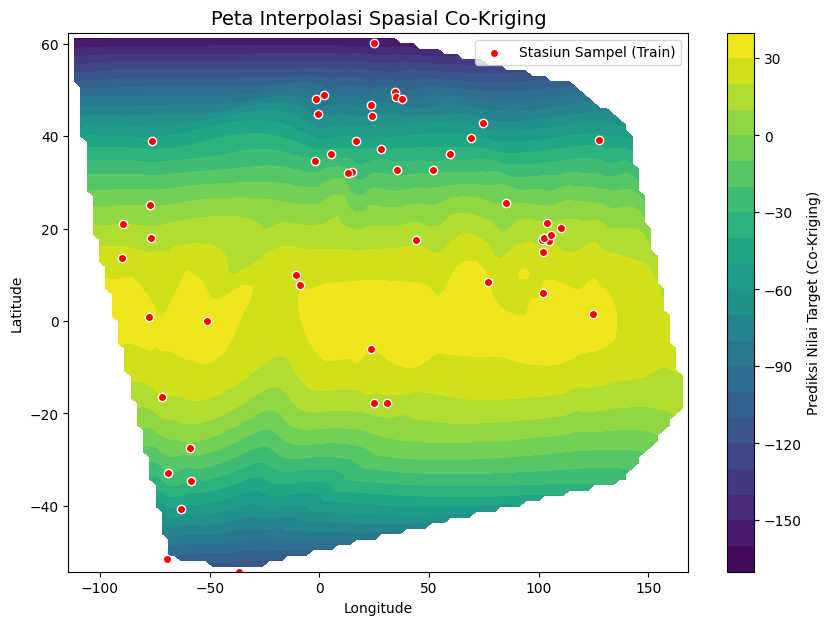

In [6]:
# ==============================================================================
# 1. INSTALL LIBRARY & IMPORT DEPENDENCIES
# ==============================================================================
!pip install pykrige matplotlib seaborn scikit-learn pandas numpy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from sklearn.metrics import r2_score, mean_squared_error
from pykrige.uk import UniversalKriging
from scipy.interpolate import griddata

# Set random seed untuk hasil reproducible
np.random.seed(42)

# ==============================================================================
# 2. UPLOAD & BACA DATA CITIES.CSV
# ==============================================================================
print("Silakan upload file 'cities.csv' Anda:")
uploaded = files.upload()

# Membaca data lokasi stasiun/kota
df = pd.read_csv('cities.csv')

# Menghapus data tanpa koordinat jika ada
df = df.dropna(subset=['latitude', 'longitude']).copy()

# Mengambil sampel 150 stasiun agar komputasi cepat & stabil
df_sample = df.sample(n=150, random_state=42).reset_index(drop=True)

# ==============================================================================
# 3. SIMULASI VARIABEL KONTINU BERKORELASI TINGGI (r > 0.8)
# ==============================================================================
# Variabel Sekunder (X): Covariate / Tekanan Udara
df_sample['X_secondary'] = 1013 - 0.08 * df_sample['latitude']**2 + np.random.normal(0, 2, len(df_sample))

# Variabel Utama (Y): Target Suhu Udara
df_sample['Y_primary'] = 25 + 0.65 * (df_sample['X_secondary'] - 1000) + np.random.normal(0, 1.2, len(df_sample))

# Evaluasi Korelasi Pearson
corr = df_sample['Y_primary'].corr(df_sample['X_secondary'])
print(f"\n--- EVALUASI HUBUNGAN VARIABEL ---")
print(f"Korelasi Pearson (r): {corr:.4f}")

# ==============================================================================
# 4. MEMBAGI DATA TRAIN & TEST (CROSS VALIDATION)
# ==============================================================================
mask_sampled = np.random.rand(len(df_sample)) < 0.4
train_df = df_sample[mask_sampled].copy()
test_df = df_sample[~mask_sampled].copy()

print(f"Jumlah Stasiun Sampel Utama (Train): {len(train_df)}")
print(f"Jumlah Stasiun Uji/Prediksi (Test): {len(test_df)}")

# ==============================================================================
# 5. PEMODELAN CO-KRIGING & ANALISIS SEMIVARIOGRAM
# ==============================================================================
# Inisialisasi Universal Kriging dengan Model Variogram Spherical
uk = UniversalKriging(
    x=train_df['longitude'].values,
    y=train_df['latitude'].values,
    z=train_df['Y_primary'].values,
    variogram_model='spherical',  # Pilihan: 'spherical', 'exponential', 'gaussian'
    drift_terms=['specified'],
    specified_drift=[train_df['X_secondary'].values]
)

# --- VISUALISASI EKSPLISIT SEMIVARIOGRAM ---
plt.figure(figsize=(8, 5))
# Plot Experimental Variogram (Titik-titik jarak lag vs Semivariansi)
plt.plot(uk.lags, uk.semivariance, 'bo', label='Experimental Semivariogram')
# Plot Fitted Variogram Model (Garis kontinu hasil fitting)
plt.plot(uk.lags, uk.variogram_function(uk.variogram_model_parameters, uk.lags), 'r-', label=f'Fitted Model ({uk.variogram_model.capitalize()})')

plt.title("Experimental Semivariogram and Fitted Model", fontsize=13)
plt.xlabel("Spatial Distance (Lag)", fontsize=11)
plt.ylabel("Semivariance $\gamma(h)$", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# Menampilkan Parameter Variogram (Nugget, Sill, Range)
print("\n--- PARAMETER VARIOGRAM TERFITTING ---")
print(f"Model Variogram: {uk.variogram_model}")
print(f"Parameters (Sill, Range, Nugget): {uk.variogram_model_parameters}")

# ==============================================================================
# 6. PREDIKSI PADA DATA TEST & EVALUASI AKURASI
# ==============================================================================
y_pred, y_var = uk.execute(
    'points',
    test_df['longitude'].values,
    test_df['latitude'].values,
    specified_drift_arrays=[test_df['X_secondary'].values]
)

r2 = r2_score(test_df['Y_primary'], y_pred)
rmse = np.sqrt(mean_squared_error(test_df['Y_primary'], y_pred))

print("\n--- HASIL EVALUASI MODEL CO-KRIGING ---")
print(f"R-Squared (R²): {r2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

# Plot Perbandingan Aktual vs Prediksi
plt.figure(figsize=(7, 5))
plt.scatter(test_df['Y_primary'], y_pred, color='blue', alpha=0.7, edgecolors='k')
plt.plot([test_df['Y_primary'].min(), test_df['Y_primary'].max()],
         [test_df['Y_primary'].min(), test_df['Y_primary'].max()], 'r--', lw=2)
plt.xlabel("Nilai Aktual (Y_primary)")
plt.ylabel("Nilai Prediksi Co-Kriging")
plt.title(f"Akurasi Prediksi Co-Kriging (R² = {r2:.3f})", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ==============================================================================
# 7. INTERPOLASI SPASIAL PETA KONTUR (GRID MAP)
# ==============================================================================
grid_lon = np.linspace(df_sample['longitude'].min(), df_sample['longitude'].max(), 100)
grid_lat = np.linspace(df_sample['latitude'].min(), df_sample['latitude'].max(), 100)
grid_x, grid_y = np.meshgrid(grid_lon, grid_lat)

grid_sec = griddata(
    (df_sample['longitude'], df_sample['latitude']),
    df_sample['X_secondary'],
    (grid_x, grid_y),
    method='cubic'
)

z_grid, ss_grid = uk.execute(
    'grid',
    grid_lon,
    grid_lat,
    specified_drift_arrays=[grid_sec]
)

# Visualisasi Peta Kontur Prediksi
plt.figure(figsize=(10, 7))
plt.contourf(grid_x, grid_y, z_grid, levels=20, cmap='viridis')
plt.colorbar(label='Prediksi Nilai Target (Co-Kriging)')
plt.scatter(train_df['longitude'], train_df['latitude'], c='red', edgecolor='white', label='Stasiun Sampel (Train)')
plt.title("Peta Interpolasi Spasial Co-Kriging", fontsize=14)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()